#Environment description



## STATE (Environment State)

The state represents the current situation of the supermarket.

It includes:

- Open Cashiers: number of active cashiers
- Queue level for each cashier

### State Representation

(num_cash_open, q1_bin, q2_bin, q3_bin, q4_bin, q5_bin)


### Queue Discretization

| Queue Size | Bin Value |
|------------|-----------|
| 0 customers | 0 |
| 1–4 customers | 1 |
| 5–10 customers | 2 |
| More than 10 customers | 3 |

### Example State

(2, 2, 1, 0, 0, 0)

### Meaning

- 2 cashiers are open
- Queue 1 has medium congestion (5–10 customers)
- Queue 2 has low congestion (1–4 customers)
- Queues 3–5 are empty

## ACTIONS (Agent Decisions)

| Action ID | Action Name | Effect |
|------------|-------------|---------|
| 0 | Open Cashier | Opens a new cashier if maximum limit is not reached |
| 1 | Close Cashier | Closes a cashier if more than one cashier is open |
| 2 | Redirect Customer | Moves one customer from the busiest queue to the shortest queue |
| 3 | Do Nothing | Keeps the environment unchanged |

## STEP FUNCTION (One Simulation Step)

Each step in the environment follows this process:

1. Agent chooses an action
2. Action is applied to environment
3. New customers arrive randomly
4. Cashiers serve customers
5. Environment state is updated
6. Reward is calculated
7. Next state is returned

## STEP OUTPUT

Each step returns:

- Next State → updated environment state
- Reward → performance score
- Done → whether episode finished or not

### Example Output:
Next State: (3, 2, 1, 0, 0, 0)  
Reward: -12  
Done: False

## Summary

- State = current supermarket situation
- Action = decision made by agent
- Step = one time unit in simulation
- Reward = feedback for learning

# Goal of the Agent(Reward)

The agent acts as a supermarket manager aiming to balance:

Reducing customer waiting time (queues)
Minimizing operational cost (number of open cashiers)

# Trade-off

More cashiers → faster service but higher cost
Fewer cashiers → lower cost but longer queues

# Penalties

Long queues

High waiting time

queues exceeding the limit

Unnecessary open cashiers

# Rewards
Short queues

Balanced workload

Efficient cashier usage

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt


# ENVIRONMENT
class SmartStoreEnv:

    def __init__(self):

        self.max_cashiers = 5
        self.max_queue = 20

        self.reset()

    # RESET
    def reset(self):

        self.open_cashiers = 1

        self.queues = [0 for _ in range(self.max_cashiers)]

        self.time_step = 0

        return self.get_state()


    # STATE DISCRETIZATION
    def get_state(self):

        def get_bin(q_size):

            if q_size == 0:
                return 0

            elif q_size <= 4:
                return 1

            elif q_size <= 10:
                return 2

            else:
                return 3

        return (

            self.open_cashiers,

            get_bin(self.queues[0]),
            get_bin(self.queues[1]),
            get_bin(self.queues[2]),
            get_bin(self.queues[3]),
            get_bin(self.queues[4])

        )

    # CUSTOMER ARRIVAL
    def generate_customers(self):

        # Rush hour simulation

        if self.time_step % 20 < 10:

            incoming = random.randint(2, 5)

        else:

            incoming = random.randint(3, 6)

        open_queues = self.queues[:self.open_cashiers]

        if len(open_queues) == 0:
            return

        # Customers prefer shorter queues

        weights = [1 / (q + 1) for q in open_queues]

        for _ in range(incoming):

            shortest_index = random.choices(
                range(len(open_queues)),
                weights=weights
            )[0]

            if self.queues[shortest_index] < self.max_queue:

                self.queues[shortest_index] += 1

    # CASHIER SERVICE
    def serve_customers(self):

        for i in range(self.open_cashiers):

            served = random.choices(
                [0, 1, 2, 3],
                weights=[5, 20, 50, 25]
            )[0]

            self.queues[i] = max(
                0,
                self.queues[i] - served
            )

    # REDIRECT CUSTOMER
    def redirect_customer(self):

        if self.open_cashiers <= 1:
            return

        max_idx = np.argmax(
            self.queues[:self.open_cashiers]
        )

        min_idx = np.argmin(
            self.queues[:self.open_cashiers]
        )

        if self.queues[max_idx] > 0:

            self.queues[max_idx] -= 1

            self.queues[min_idx] += 1

    # ACTIONS
    def apply_action(self, action):

        """
        ACTIONS

        0 -> Open Cashier
        1 -> Close Cashier
        2 -> Redirect Customer
        3 -> Do Nothing
        """

        if action == 0 and self.open_cashiers < self.max_cashiers:

            self.open_cashiers += 1

        elif action == 1 and self.open_cashiers > 1:

            self.open_cashiers -= 1

        elif action == 2:

            self.redirect_customer()

        elif action == 3:

            pass

    # STEP FUNCTION
    def step(self, action):

        # Apply action

        self.apply_action(action)

        # Update environment

        self.generate_customers()

        self.serve_customers()

        self.time_step += 1

        # REWARD FUNCTION
        total_queue = sum(
            self.queues[:self.open_cashiers]
        )

        waiting_penalty = total_queue * 1.5

        cashier_cost = self.open_cashiers * 2.0

        imbalance = np.std(
            self.queues[:self.open_cashiers]
        )

        reward = (
            -waiting_penalty
            -cashier_cost
            -imbalance
        )

        # Heavy congestion penalty

        reward -= max(
            self.queues[:self.open_cashiers]
        ) * 2

        # Bonus for opening cashier during congestion

        if action == 0 and total_queue > 15:

            reward += 10

        # Bonus for closing cashier during low traffic

        if (
            action == 1
            and total_queue < 3
            and self.open_cashiers > 1
        ):

            reward += 5

        # Bonus for maintaining low congestion

        if total_queue < 5:

            reward += 15

        # TERMINATION
        done = self.time_step >= 100

        next_state = self.get_state()

        return next_state, reward, done

# Q-LEARNING

## Q-LEARNING AGENT

In [ ]:
# Q-LEARNING AGENT
class QLearningAgent:

    def __init__(self,
                 action_size=4,
                 alpha=0.1,
                 gamma=0.95,
                 epsilon=1.0,
                 epsilon_decay=0.995,
                 epsilon_min=0.01):

        self.action_size = action_size

        self.alpha = alpha

        self.gamma = gamma

        self.epsilon = epsilon

        self.epsilon_decay = epsilon_decay

        self.epsilon_min = epsilon_min

        self.q_table = {}

    # GET Q VALUES
    def get_q_values(self, state):

        if state not in self.q_table:

            self.q_table[state] = np.zeros(
                self.action_size
            )

        return self.q_table[state]

    # EPSILON GREEDY POLICY
    def choose_action(self, state):

        if random.random() < self.epsilon:

            return random.randint(
                0,
                self.action_size - 1
            )

        q_values = self.get_q_values(state)

        return np.argmax(q_values)

    # Q-LEARNING UPDATE
    def learn(self,
              state,
              action,
              reward,
              next_state,
              done):

        current_q = self.get_q_values(state)

        next_q = self.get_q_values(next_state)

        max_next_q = (
            0 if done else np.max(next_q)
        )

        current_q[action] += self.alpha * (

            reward
            + self.gamma * max_next_q
            - current_q[action]

        )

        self.q_table[state] = current_q

    # EPSILON DECAY
    def decay_epsilon(self):

        if self.epsilon > self.epsilon_min:

            self.epsilon *= self.epsilon_decay

## TRAINING

In [ ]:
# TRAINING
env = SmartStoreEnv()

agent = QLearningAgent()

episodes = 1000

rewards_history = []

epsilon_history = []

print("Starting Q-Learning Agent Training...\n")

for episode in range(episodes):

    state = env.reset()

    total_reward = 0

    done = False

    while not done:

        # Choose action

        action = agent.choose_action(
            state
        )

        # Environment step

        next_state, reward, done = env.step(
            action
        )

        # Learn

        agent.learn(
            state,
            action,
            reward,
            next_state,
            done
        )

        state = next_state

        total_reward += reward

    # Decay epsilon

    agent.decay_epsilon()

    # Save history

    rewards_history.append(total_reward)

    epsilon_history.append(agent.epsilon)

    # Print progress

    if (episode + 1) % 50 == 0:

        print(
            f"Episode: {episode+1}/{episodes} "
            f"| Reward: {total_reward:.2f} "
            f"| Epsilon: {agent.epsilon:.4f}"
        )

print("\n Training Completed Successfully!")


# BEST TRAINING REWARD
best_reward = max(rewards_history)

print("\nBest Training Reward:", round(best_reward, 2))

Starting Q-Learning Agent Training...

Episode: 50/1000 | Reward: -638.55 | Epsilon: 0.7783
Episode: 100/1000 | Reward: -77.55 | Epsilon: 0.6058
Episode: 150/1000 | Reward: -492.28 | Epsilon: 0.4715
Episode: 200/1000 | Reward: -8.50 | Epsilon: 0.3670
Episode: 250/1000 | Reward: 465.74 | Epsilon: 0.2856
Episode: 300/1000 | Reward: 532.71 | Epsilon: 0.2223
Episode: 350/1000 | Reward: 483.72 | Epsilon: 0.1730
Episode: 400/1000 | Reward: 426.95 | Epsilon: 0.1347
Episode: 450/1000 | Reward: 510.42 | Epsilon: 0.1048
Episode: 500/1000 | Reward: 454.57 | Epsilon: 0.0816
Episode: 550/1000 | Reward: 371.29 | Epsilon: 0.0635
Episode: 600/1000 | Reward: 527.79 | Epsilon: 0.0494
Episode: 650/1000 | Reward: 474.52 | Epsilon: 0.0385
Episode: 700/1000 | Reward: 374.69 | Epsilon: 0.0299
Episode: 750/1000 | Reward: 458.83 | Epsilon: 0.0233
Episode: 800/1000 | Reward: 466.10 | Epsilon: 0.0181
Episode: 850/1000 | Reward: 439.41 | Epsilon: 0.0141
Episode: 900/1000 | Reward: 629.15 | Epsilon: 0.0110
Episode

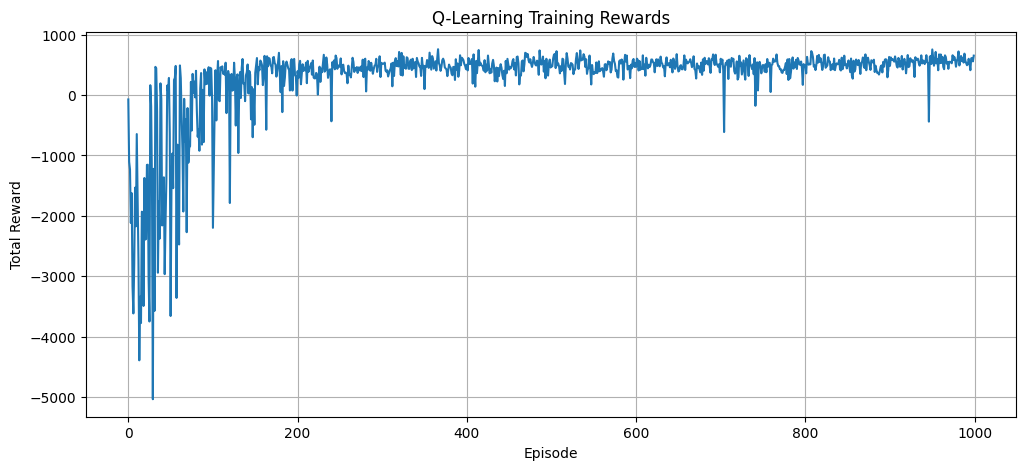

In [ ]:
# REWARD PLOT
plt.figure(figsize=(12, 5))

plt.plot(rewards_history)

plt.xlabel("Episode")

plt.ylabel("Total Reward")

plt.title("Q-Learning Training Rewards")

plt.grid()

plt.show()


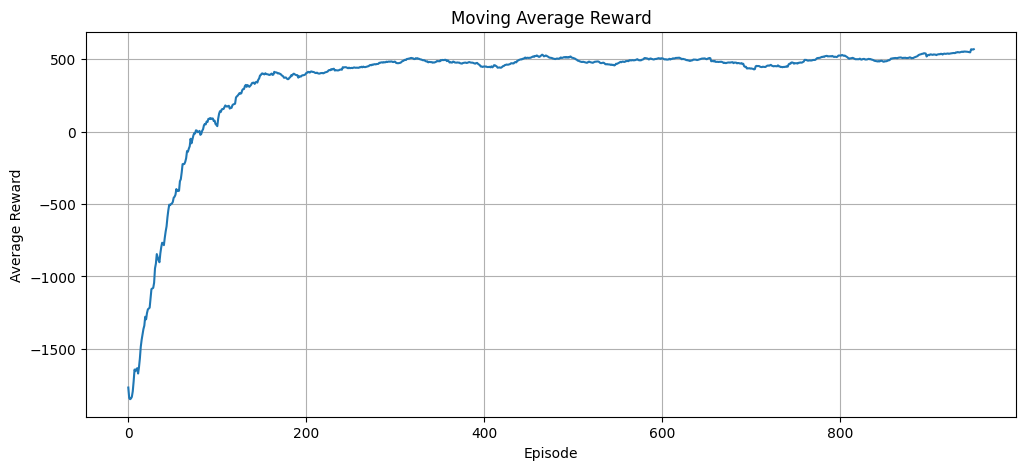

In [ ]:
# MOVING AVERAGE PLOT
window = 50

moving_average = np.convolve(
    rewards_history,
    np.ones(window) / window,
    mode='valid'
)

plt.figure(figsize=(12, 5))

plt.plot(moving_average)

plt.xlabel("Episode")

plt.ylabel("Average Reward")

plt.title("Moving Average Reward")

plt.grid()

plt.show()

## EVALUATION

In [ ]:
# EVALUATION PHASE
print("\nStarting Evaluation Phase...\n")

agent.epsilon = 0

test_rewards = []

for episode in range(10):

    state = env.reset()

    done = False

    total_reward = 0

    while not done:

        action = agent.choose_action(state)

        next_state, reward, done = env.step(
            action
        )

        state = next_state

        total_reward += reward

    test_rewards.append(total_reward)

    print(
        f"Test Episode {episode+1} "
        f"| Reward = {total_reward:.2f}"
    )


# AVERAGE EVALUATION REWARD
avg_reward = np.mean(test_rewards)

print(
    "\nAverage Evaluation Reward:",
    round(avg_reward, 2)
)


Starting Evaluation Phase...

Test Episode 1 | Reward = 701.90
Test Episode 2 | Reward = 489.76
Test Episode 3 | Reward = 690.83
Test Episode 4 | Reward = 439.31
Test Episode 5 | Reward = 522.90
Test Episode 6 | Reward = 657.37
Test Episode 7 | Reward = 587.28
Test Episode 8 | Reward = 690.17
Test Episode 9 | Reward = 441.30
Test Episode 10 | Reward = 634.13

Average Evaluation Reward: 585.49


# SARSA

## SARSA AGENT

In [ ]:
# SARSA AGENT
class SARSAAgent:

    def __init__(self,
                 action_size=4,
                 alpha=0.1,
                 gamma=0.95,
                 epsilon=1.0,
                 epsilon_decay=0.995,
                 epsilon_min=0.01):

        self.action_size = action_size
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_table = {}

    # GET Q VALUES
    def get_q_values(self, state):
        if state not in self.q_table:
            self.q_table[state] = np.zeros(self.action_size)
        return self.q_table[state]

    # EPSILON GREEDY POLICY
    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)

        q_values = self.get_q_values(state)
        return np.argmax(q_values)

    # SARSA UPDATE (On-Policy)
    def learn(self, state, action, reward, next_state, next_action, done):
        current_q = self.get_q_values(state)
        next_q = self.get_q_values(next_state)

        # If done, next Q value is 0, else it takes the Q-value of the NEXT CHOSEN ACTION
        next_q_value = 0 if done else next_q[next_action]

        # SARSA Equation Update
        current_q[action] += self.alpha * (
            reward
            + self.gamma * next_q_value
            - current_q[action]
        )

        self.q_table[state] = current_q

    # EPSILON DECAY
    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

## Traning

In [ ]:
# TRAINING SARSA AGENT
sarsa_env = SmartStoreEnv()
sarsa_agent = SARSAAgent()

episodes = 1000
sarsa_rewards_history = []
sarsa_epsilon_history = []

print("Starting SARSA Agent Training...\n")

for episode in range(episodes):
    state = sarsa_env.reset()
    total_reward = 0
    done = False

    # Choose first action (S) -> (A)
    action = sarsa_agent.choose_action(state)

    while not done:
        # Take step with action (A), observe (R) and (S')
        next_state, reward, done = sarsa_env.step(action)

        # Choose next action (A') from next state (S') using current policy
        next_action = sarsa_agent.choose_action(next_state)

        # Learn using SARSA update (S, A, R, S', A')
        sarsa_agent.learn(state, action, reward, next_state, next_action, done)

        # Move to next state and action
        state = next_state
        action = next_action

        total_reward += reward

    # Decay epsilon after each episode
    sarsa_agent.decay_epsilon()

    # Save history
    sarsa_rewards_history.append(total_reward)
    sarsa_epsilon_history.append(sarsa_agent.epsilon)

    # Print progress
    if (episode + 1) % 50 == 0:
        print(
            f"Episode: {episode+1}/{episodes} "
            f"| Reward: {total_reward:.2f} "
            f"| Epsilon: {sarsa_agent.epsilon:.4f}"
        )

print("\n SARSA Training Completed Successfully!")

best_sarsa_reward = max(sarsa_rewards_history)
print("\nBest SARSA Training Reward:", round(best_sarsa_reward, 2))

Starting SARSA Agent Training...

Episode: 50/1000 | Reward: -476.06 | Epsilon: 0.7783
Episode: 100/1000 | Reward: 510.24 | Epsilon: 0.6058
Episode: 150/1000 | Reward: 501.55 | Epsilon: 0.4715
Episode: 200/1000 | Reward: 396.15 | Epsilon: 0.3670
Episode: 250/1000 | Reward: 551.69 | Epsilon: 0.2856
Episode: 300/1000 | Reward: 539.80 | Epsilon: 0.2223
Episode: 350/1000 | Reward: 592.64 | Epsilon: 0.1730
Episode: 400/1000 | Reward: 599.02 | Epsilon: 0.1347
Episode: 450/1000 | Reward: 480.60 | Epsilon: 0.1048
Episode: 500/1000 | Reward: 596.20 | Epsilon: 0.0816
Episode: 550/1000 | Reward: 401.07 | Epsilon: 0.0635
Episode: 600/1000 | Reward: 616.63 | Epsilon: 0.0494
Episode: 650/1000 | Reward: 426.99 | Epsilon: 0.0385
Episode: 700/1000 | Reward: 521.82 | Epsilon: 0.0299
Episode: 750/1000 | Reward: 354.54 | Epsilon: 0.0233
Episode: 800/1000 | Reward: 396.87 | Epsilon: 0.0181
Episode: 850/1000 | Reward: 553.26 | Epsilon: 0.0141
Episode: 900/1000 | Reward: 533.89 | Epsilon: 0.0110
Episode: 950

## EVALUATION

In [ ]:
# SARSA EVALUATION PHASE
print("\nStarting SARSA Evaluation Phase...\n")

sarsa_agent.epsilon = 0
sarsa_test_rewards = []

for episode in range(10):
    state = sarsa_env.reset()
    done = False
    total_reward = 0

    while not done:
        action = sarsa_agent.choose_action(state)
        next_state, reward, done = sarsa_env.step(action)
        state = next_state
        total_reward += reward

    sarsa_test_rewards.append(total_reward)
    print(f"Test Episode {episode+1} | Reward = {total_reward:.2f}")

avg_sarsa_reward = np.mean(sarsa_test_rewards)
print("\nAverage SARSA Evaluation Reward:", round(avg_sarsa_reward, 2))


Starting SARSA Evaluation Phase...

Test Episode 1 | Reward = 423.23
Test Episode 2 | Reward = 395.86
Test Episode 3 | Reward = 436.57
Test Episode 4 | Reward = 476.72
Test Episode 5 | Reward = 456.67
Test Episode 6 | Reward = 393.17
Test Episode 7 | Reward = 374.71
Test Episode 8 | Reward = 408.32
Test Episode 9 | Reward = 445.53
Test Episode 10 | Reward = 481.86

Average SARSA Evaluation Reward: 429.27


# Evaluation & Analysis

## Plot 1 — Learning Curves (with moving average)

In [ ]:
qlearning_agent = agent
trained_sarsa_agent = sarsa_agent

ql_rewards = rewards_history
sarsa_rewards = sarsa_rewards_history

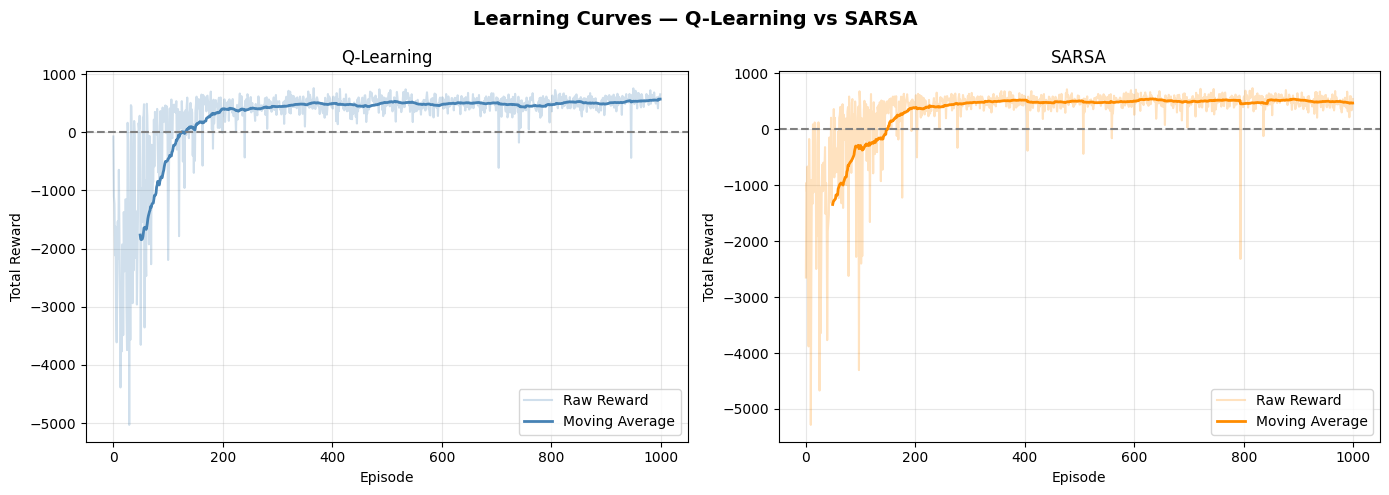

In [ ]:
import numpy as np

# HELPERS
def moving_average(data, window):
    return np.convolve(data, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Learning Curves — Q-Learning vs SARSA', fontsize=14, fontweight='bold')

for ax, rewards, label, color in zip(
    axes,
    [ql_rewards, sarsa_rewards],
    ['Q-Learning', 'SARSA'],
    ['steelblue', 'darkorange']
):

    ax.plot(rewards, alpha=0.25, color=color, label='Raw Reward')

    ma = moving_average(rewards, 50)

    ax.plot(range(49, len(rewards)), ma,
            color=color, linewidth=2,
            label='Moving Average')

    ax.axhline(0, color='gray', linestyle='--')

    ax.set_title(label)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# =========================================================
# HELPERS
# =========================================================

bin_labels = ['Empty(0)', 'Low(1)', 'Medium(2)', 'High(3)']

def make_qvalue_grid(current_agent, cashiers=2, n_bins=4):

    grid = np.full((n_bins, n_bins), np.nan)

    for q1 in range(n_bins):
        for q2 in range(n_bins):

            state = (cashiers, q1, q2, 0, 0, 0)

            if state in current_agent.q_table:
                grid[q1, q2] = np.max(current_agent.q_table[state])

    return grid

def make_policy_grid(current_agent, cashiers=2, n_bins=4):

    grid = np.full((n_bins, n_bins), -1)

    for q1 in range(n_bins):
        for q2 in range(n_bins):

            state = (cashiers, q1, q2, 0, 0, 0)

            if state in current_agent.q_table:
                grid[q1, q2] = np.argmax(current_agent.q_table[state])

    return grid

## PLOT 2: Q-VALUE HEATMAP

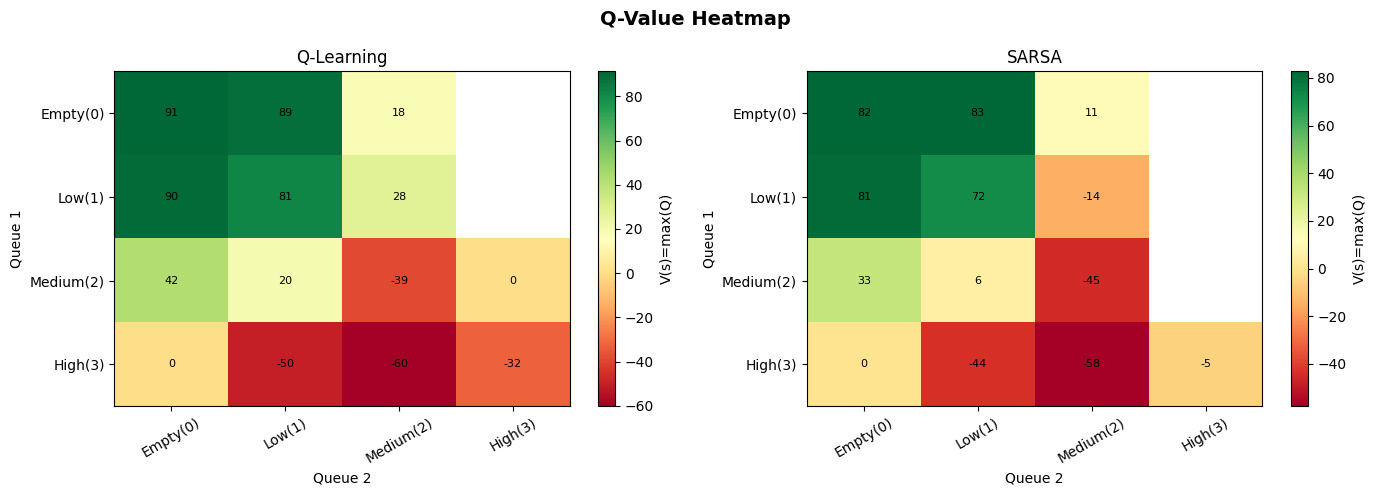

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Q-Value Heatmap', fontsize=14, fontweight='bold')

for ax, current_agent, label in zip(
    axes,
    [qlearning_agent, trained_sarsa_agent],
    ['Q-Learning', 'SARSA']
):

    grid = make_qvalue_grid(current_agent, cashiers=2)

    im = ax.imshow(grid, cmap='RdYlGn', aspect='auto')

    plt.colorbar(im, ax=ax, label='V(s)=max(Q)')

    ax.set_title(label)
    ax.set_xlabel('Queue 2')
    ax.set_ylabel('Queue 1')

    ax.set_xticks(range(4))
    ax.set_xticklabels(bin_labels, rotation=30)

    ax.set_yticks(range(4))
    ax.set_yticklabels(bin_labels)

    for i in range(4):
        for j in range(4):

            value = grid[i, j]

            if not np.isnan(value):
                ax.text(j, i, f'{value:.0f}',
                        ha='center', va='center',
                        fontsize=8)

plt.tight_layout()
plt.show()

## Plot 3 — Policy Visualization

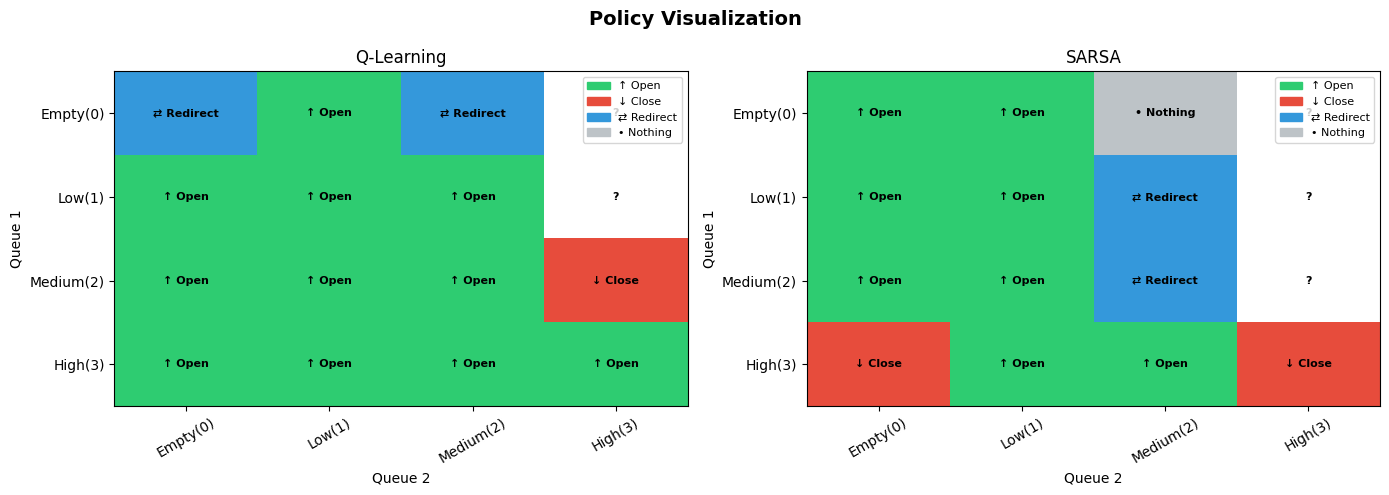

In [ ]:
import matplotlib.patches as mpatches

action_symbols = {
    0: '↑ Open',
    1: '↓ Close',
    2: '⇄ Redirect',
    3: '• Nothing',
    -1: '?'
}

action_colors = {
    0: '#2ecc71',
    1: '#e74c3c',
    2: '#3498db',
    3: '#bdc3c7',
    -1: 'white'
}

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Policy Visualization', fontsize=14, fontweight='bold')

for ax, current_agent, label in zip(
    axes,
    [qlearning_agent, trained_sarsa_agent],
    ['Q-Learning', 'SARSA']
):

    grid = make_policy_grid(current_agent, cashiers=2)

    color_grid = np.zeros((*grid.shape, 3))

    for i in range(4):
        for j in range(4):

            action = int(grid[i, j])

            rgb = plt.matplotlib.colors.to_rgb(
                action_colors.get(action, 'white')
            )

            color_grid[i, j] = rgb

    ax.imshow(color_grid, aspect='auto')

    ax.set_title(label)
    ax.set_xlabel('Queue 2')
    ax.set_ylabel('Queue 1')

    ax.set_xticks(range(4))
    ax.set_xticklabels(bin_labels, rotation=30)

    ax.set_yticks(range(4))
    ax.set_yticklabels(bin_labels)

    for i in range(4):
        for j in range(4):

            action = int(grid[i, j])

            ax.text(j, i,
                    action_symbols.get(action, '?'),
                    ha='center', va='center',
                    fontsize=8, fontweight='bold')

    legend_patches = [
        mpatches.Patch(color=v, label=action_symbols[k])
        for k, v in action_colors.items()
        if k != -1
    ]

    ax.legend(handles=legend_patches,
              fontsize=8,
              loc='upper right')

plt.tight_layout()
plt.show()

## Plot 4 — Stability Analysis (Multiple Runs)

Running 5 independent runs...


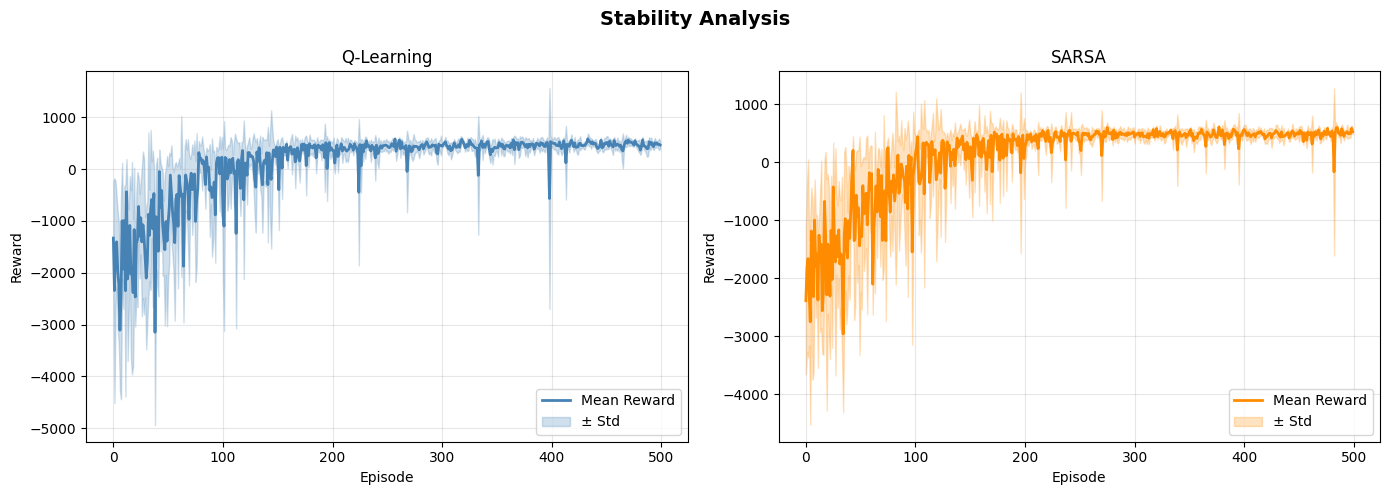

In [ ]:
N_RUNS = 5
EPISODES = 500

ql_runs = []
sarsa_runs = []

print(f'Running {N_RUNS} independent runs...')

for run in range(N_RUNS):

    seed = run * 10

    random.seed(seed)
    np.random.seed(seed)

    # =========================
    # Q-LEARNING
    # =========================

    ql_env = SmartStoreEnv()
    ql_temp_agent = QLearningAgent()

    ql_run_rewards = []

    for ep in range(EPISODES):

        state = ql_env.reset()
        done = False
        total_reward = 0

        while not done:

            action = ql_temp_agent.choose_action(state)

            next_state, reward, done = ql_env.step(action)

            ql_temp_agent.learn(
                state, action,
                reward,
                next_state,
                done
            )

            state = next_state
            total_reward += reward

        ql_temp_agent.decay_epsilon()

        ql_run_rewards.append(total_reward)

    ql_runs.append(ql_run_rewards)

    # =========================
    # SARSA
    # =========================

    sarsa_env = SmartStoreEnv()
    sarsa_temp_agent = SARSAAgent()

    sarsa_run_rewards = []

    for ep in range(EPISODES):

        state = sarsa_env.reset()

        action = sarsa_temp_agent.choose_action(state)

        done = False
        total_reward = 0

        while not done:

            next_state, reward, done = sarsa_env.step(action)

            next_action = sarsa_temp_agent.choose_action(next_state)

            sarsa_temp_agent.learn(
                state, action,
                reward,
                next_state,
                next_action,
                done
            )

            state = next_state
            action = next_action

            total_reward += reward

        sarsa_temp_agent.decay_epsilon()

        sarsa_run_rewards.append(total_reward)

    sarsa_runs.append(sarsa_run_rewards)

ql_runs = np.array(ql_runs)
sarsa_runs = np.array(sarsa_runs)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Stability Analysis', fontsize=14, fontweight='bold')

for ax, runs, label, color in zip(
    axes,
    [ql_runs, sarsa_runs],
    ['Q-Learning', 'SARSA'],
    ['steelblue', 'darkorange']
):

    mean = runs.mean(axis=0)
    std = runs.std(axis=0)

    episodes_x = np.arange(EPISODES)

    ax.plot(episodes_x, mean,
            color=color,
            linewidth=2,
            label='Mean Reward')

    ax.fill_between(
        episodes_x,
        mean - std,
        mean + std,
        alpha=0.25,
        color=color,
        label='± Std'
    )

    ax.set_title(label)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Reward')

    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


## Evaluation Metrics Table

In [ ]:
THRESHOLD     = 300   # reward threshold for sample efficiency
LAST_N        = 100   # last N episodes for final performance

def compute_metrics(rewards_list, label, threshold=THRESHOLD, last_n=LAST_N):
    rewards = np.array(rewards_list)

    # Sample efficiency: first episode exceeding threshold
    above = np.where(rewards >= threshold)[0]
    sample_eff = int(above[0]) if len(above) > 0 else -1

    # Final performance: mean of last N
    final_perf = float(np.mean(rewards[-last_n:]))


    # Stability: std of final-N rewards
    stability = float(np.std(rewards[-last_n:]))

    print(f'\n── {label} ──')
    print(f'  Sample Efficiency  (first ep ≥ {threshold}): episode {sample_eff}')
    print(f'  Final Performance  (mean last {last_n} eps):  {final_perf:.2f}')
    print(f'  Stability          (std last {last_n} eps):   {stability:.2f}')
    return dict(label=label,
                sample_efficiency=sample_eff,
                final_performance=round(final_perf, 2),
                stability=round(stability, 2))

ql_metrics    = compute_metrics(ql_rewards,    'Q-Learning')
sarsa_metrics = compute_metrics(sarsa_rewards, 'SARSA')

print('\n' + '='*55)
print(f"{'Metric':<28} {'Q-Learning':>12} {'SARSA':>12}")
print('='*55)
for key in ['sample_efficiency','final_performance','convergence_speed','stability']:
    print(f"{key:<28} {str(ql_metrics[key]):>12} {str(sarsa_metrics[key]):>12}")
print('='*55)



── Q-Learning ──
  Sample Efficiency  (first ep ≥ 300): episode 32
  Final Performance  (mean last 100 eps):  548.71
  Convergence Speed  (ep where MA stabilises): 50
  Stability          (std last 100 eps):   125.67

── SARSA ──
  Sample Efficiency  (first ep ≥ 300): episode 51
  Final Performance  (mean last 100 eps):  483.03
  Convergence Speed  (ep where MA stabilises): 50
  Stability          (std last 100 eps):   98.96

Metric                         Q-Learning        SARSA
sample_efficiency                      32           51
final_performance                  548.71       483.03
convergence_speed                      50           50
stability                          125.67        98.96


## Combined Comparison Plot

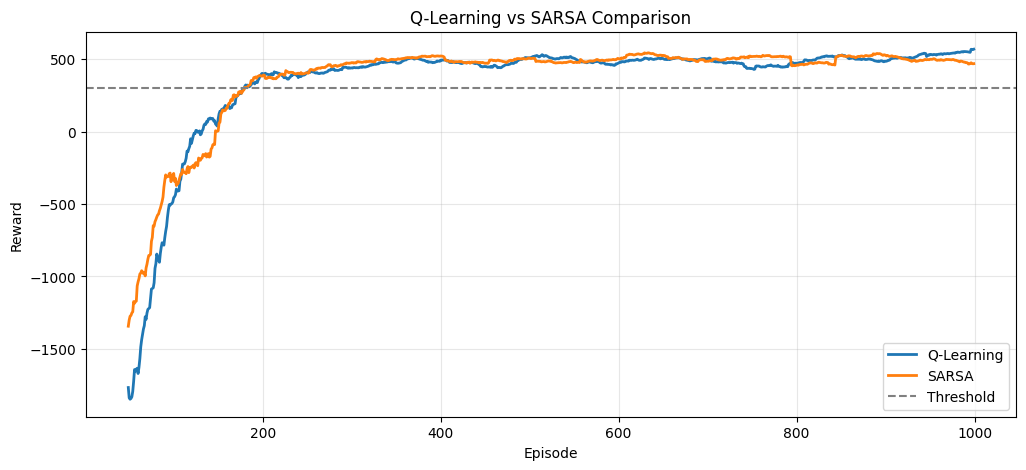

In [ ]:

plt.figure(figsize=(12,5))

ql_ma = moving_average(ql_rewards, 50)

sarsa_ma = moving_average(sarsa_rewards, 50)

episodes_x = np.arange(49, len(ql_rewards))

plt.plot(
    episodes_x,
    ql_ma,
    linewidth=2,
    label='Q-Learning'
)

plt.plot(
    episodes_x,
    sarsa_ma,
    linewidth=2,
    label='SARSA'
)

plt.axhline(
    THRESHOLD,
    linestyle='--',
    color='gray',
    label='Threshold'
)

plt.title('Q-Learning vs SARSA Comparison')

plt.xlabel('Episode')

plt.ylabel('Reward')

plt.grid(alpha=0.3)

plt.legend()

plt.show()